# 📊 Annual Labour Force Statistics by Sex

## Dataset Description
This dataset contains **annual principal labour force statistics** for Malaysia, broken down by **sex**. It covers the employment, unemployment, and participation rates for the Malaysian workforce, published by DOSM from the **Labour Force Survey (LFS)**.

## Data Source
| Field | Detail |
|---|---|
| **Publisher** | Department of Statistics Malaysia (DOSM) |
| **Survey** | Labour Force Survey (LFS), annual |
| **Catalogue page** | https://open.dosm.gov.my/data-catalogue/lfs_year_sex |
| **Parquet URL** | `https://storage.dosm.gov.my/labour/lfs_year_sex.parquet` |
| **License** | CC BY 4.0 |
| **Coverage** | 1982 – 2023 |

## Column Descriptions
| Column | Type | Description |
|---|---|---|
| `date` | date | Year of survey |
| `sex` | string | `overall`, `male`, or `female` |
| `lf` | integer | Labour force size (thousands) |
| `lf_employed` | integer | Number employed (thousands) |
| `lf_unemployed` | integer | Number unemployed (thousands) |
| `lf_outside` | integer | Outside labour force (thousands) |
| `p_rate` | float | Labour force participation rate (%) |
| `ep_ratio` | float | Employment-to-population ratio (%) |
| `u_rate` | float | Unemployment rate (%) |

## Relevance to EduNilai
Unemployment rate by sex is critical for the ROI model — an unemployed graduate earns zero, not a salary. The gender gap in participation rate also helps explain why female graduates may have lower measured ROI despite similar qualifications.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

URL = 'https://storage.dosm.gov.my/labour/lfs_year_sex.parquet'
df = pd.read_parquet(URL)
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

df

,sex,date,lf,lf_employed,lf_unemployed,lf_outside,p_rate,u_rate,ep_ratio
0,both,1982-01-01,5431.400000,5249.000000,182.400000,2944.600000,64.800000,3.400000,62.5
1,both,1983-01-01,5671.800000,5457.000000,214.900000,2969.400000,65.600000,3.800000,62.8
2,both,1984-01-01,5862.500000,5566.700000,295.800000,3119.600000,65.300000,5.000000,62.1
3,both,1985-01-01,5990.100000,5653.400000,336.800000,3124.900000,65.700000,5.600000,61.3
4,both,1986-01-01,6222.100000,5760.100000,461.900000,3188.300000,66.100000,7.400000,60.5
...,...,...,...,...,...,...,...,...,...
115,male,2019-01-01,9503.500000,9202.400000,301.100000,2253.500000,80.800000,3.200000,78.3
116,male,2020-01-01,9566.208962,9151.193449,415.015513,2342.339345,80.330606,4.338349,76.9
117,male,2021-01-01,9622.999776,9194.605766,428.394009,2326.820849,80.528404,4.451772,77.1
118,male,2022-01-01,9776.180885,9402.124034,374.056851,2217.178182,81.513284,3.826206,78.4


In [4]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nYear range:", df['date'].dt.year.min(), "–", df['date'].dt.year.max())
print("\nLatest year (overall):")
latest = df[df['date'] == df['date'].max()]
print(latest.to_string(index=False))

Shape: (120, 9)
Columns: ['sex', 'date', 'lf', 'lf_employed', 'lf_unemployed', 'lf_outside', 'p_rate', 'u_rate', 'ep_ratio']

Year range: 1982 – 2023

Latest year (overall):
   sex       date           lf  lf_employed  lf_unemployed  lf_outside    p_rate   u_rate  ep_ratio
  both 2023-01-01 16366.800000 15813.400000     553.400000 6997.800000 70.000000 3.400000      67.7
female 2023-01-01  6178.316033  5963.820006     214.496026 4809.503086 56.228774 3.471755      54.3
  male 2023-01-01 10188.497612  9849.548320     338.949292 2188.335626 82.319099 3.326784      79.6


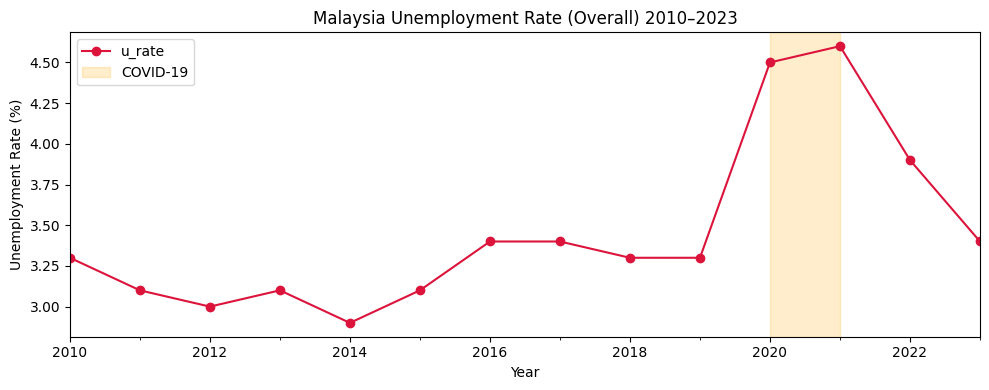

In [5]:
# Filter 2010 onwards
df_2010 = df[df['date'].dt.year >= 2010].copy()
df_overall = df_2010[df_2010['sex'] == 'both'] if 'sex' in df_2010.columns else df_2010

# Plot unemployment rate trend
if 'u_rate' in df_overall.columns:
    df_overall.set_index('date')['u_rate'].plot(marker='o', figsize=(10, 4), color='crimson')
    plt.title('Malaysia Unemployment Rate (Overall) 2010–2023')
    plt.ylabel('Unemployment Rate (%)')
    plt.xlabel('Year')
    plt.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2021-01-01'), alpha=0.2, color='orange', label='COVID-19')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# check df_2010 before exporting to csv
df_2010

,sex,date,lf,lf_employed,lf_unemployed,lf_outside,p_rate,u_rate,ep_ratio
26,both,2010-01-01,12303.900000,11899.500000,404.400000,7023.000000,63.700000,3.300000,61.5
27,both,2011-01-01,12740.700000,12351.500000,389.200000,7023.300000,64.500000,3.100000,62.4
28,both,2012-01-01,13221.700000,12820.500000,401.200000,6927.400000,65.600000,3.000000,63.6
29,both,2013-01-01,13980.500000,13545.400000,435.100000,6781.200000,67.300000,3.100000,65.2
30,both,2014-01-01,14263.600000,13852.600000,411.100000,6821.000000,67.600000,2.900000,65.3
31,both,2015-01-01,14518.000000,14067.700000,450.300000,6869.900000,67.900000,3.100000,65.2
32,both,2016-01-01,14667.800000,14163.700000,504.100000,6987.600000,67.700000,3.400000,64.5
33,both,2017-01-01,14980.100000,14476.800000,503.300000,7065.000000,68.000000,3.400000,64.9
34,both,2018-01-01,15280.300000,14776.000000,504.300000,7094.400000,68.300000,3.300000,65.4
35,both,2019-01-01,15581.600000,15073.400000,508.200000,7103.500000,68.700000,3.300000,66.5


In [8]:
os.makedirs('../data/salary', exist_ok=True)
df_2010.to_csv('../data/salary/lfs_annual_sex.csv', index=False, encoding='utf-8')
print("Saved -> ../data/salary/lfs_annual_sex.csv")
print(f"Rows exported: {len(df_2010)}")

Saved -> ../data/salary/lfs_annual_sex.csv
Rows exported: 42
